In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('k-mean-data.csv')
print(df.head(10))
 
# Data Summary
print('Data Summary:')
print(df[['Age', 'SpendingScore']].describe())


   CustomerID  Age  SpendingScore
0           1   19             15
1           2   21             16
2           3   20             16
3           4   23             17
4           5   18             10
5           6   22             14
6           7   19             12
7           8   25             20
8           9   24             19
9          10   21             15
Data Summary:
             Age  SpendingScore
count  50.000000      50.000000
mean   34.300000      51.540000
std    11.285262      29.110774
min    18.000000      10.000000
25%    23.250000      17.250000
50%    33.000000      51.000000
75%    46.000000      82.750000
max    53.000000      90.000000


In [14]:
# Preprocessing the data
print('Preprocessing the data...')

X = df[['Age', 'SpendingScore']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Done 👍')

Preprocessing the data...
Done 👍


In [16]:
# Best K value using Elbow Method

print('Best K value')

inertias = []
K_range = range(2, 9)
 
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")

Best K value
K=2: Inertia = 30.50
K=3: Inertia = 2.60
K=4: Inertia = 1.99
K=5: Inertia = 1.46
K=6: Inertia = 0.96
K=7: Inertia = 0.82
K=8: Inertia = 0.71


In [38]:
# Model Training with optimal K value

optimal_k = 4
print(f"Using {optimal_k} groups...")
 
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_model.fit_predict(X_scaled)
 

Using 4 groups...


In [39]:
# Analyzing the clusters

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]

✅ Chart saved as 'kmeans_analysis.png'


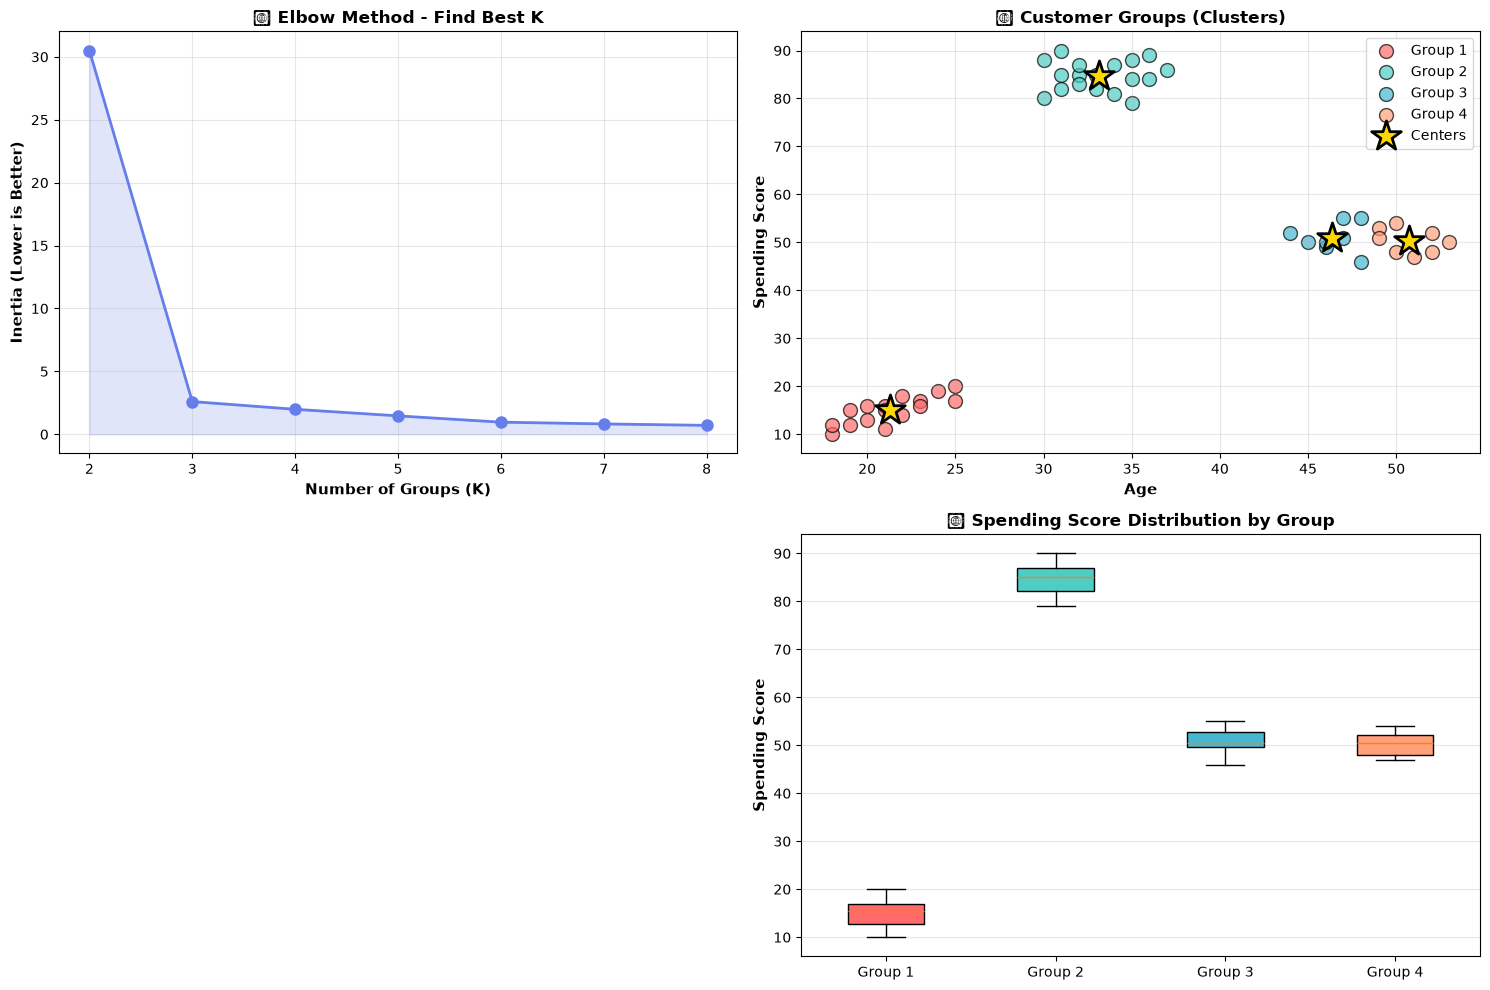

In [44]:
# Visualizing the clusters

fig = plt.figure(figsize=(15, 10))

# Plot 1: Elbow Method
ax1 = plt.subplot(2, 2, 1)
ax1.plot(K_range, inertias, 'o-', linewidth=2, markersize=8, color='#667eea')
ax1.fill_between(K_range, inertias, alpha=0.2, color='#667eea')
ax1.set_xlabel('Number of Groups (K)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inertia (Lower is Better)', fontsize=11, fontweight='bold')
ax1.set_title('📈 Elbow Method - Find Best K', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(K_range)
 
# Plot 2: Clusters Visualization
ax2 = plt.subplot(2, 2, 2)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    ax2.scatter(cluster_data['Age'], cluster_data['SpendingScore'], 
               c=colors[i], label=f'Group {i+1}', s=100, alpha=0.7, edgecolors='black')
 
# Plot centroids
centroids_original = scaler.inverse_transform(kmeans_model.cluster_centers_)
ax2.scatter(centroids_original[:, 0], centroids_original[:, 1], 
           c='gold', marker='*', s=500, edgecolors='black', linewidth=2, 
           label='Centers', zorder=5)
 
ax2.set_xlabel('Age', fontsize=11, fontweight='bold')
ax2.set_ylabel('Spending Score', fontsize=11, fontweight='bold')
ax2.set_title('🎨 Customer Groups (Clusters)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
 

 
# Plot 4: Age vs Spending by Group (Box Plot)
ax4 = plt.subplot(2, 2, 4)
data_for_box = [df[df['Cluster'] == i]['SpendingScore'].values for i in range(optimal_k)]
bp = ax4.boxplot(
    data_for_box,
    tick_labels=[f'Group {i + 1}' for i in range(optimal_k)],
    patch_artist=True
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax4.set_ylabel('Spending Score', fontsize=11, fontweight='bold')
ax4.set_title('📉 Spending Score Distribution by Group', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.savefig('kmeans_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'kmeans_analysis.png'")
plt.show()

In [37]:
# Customer Profile Analysis

print("\nCustomer Profile Analysis:")

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    avg_age = cluster_data['Age'].mean()
    avg_spending = cluster_data['SpendingScore'].mean()
    
    if avg_age < 30 and avg_spending < 50:
        profile = "Young, Low Spenders"
    elif avg_age < 40 and avg_spending < 50:
        profile = "Middle-Aged, Low Spenders"
    elif avg_age > 40 and avg_spending < 50:
        profile = "Older, Low Spenders"
    elif avg_age < 40 and avg_spending > 50:
        profile = "Young, High Spenders (Target!)"
    else:
        profile = "Older, High Spenders (VIP!)"
    
    print(f"Group {i+1}: {profile}")
    print(f"  → This group has {len(cluster_data)} customers")
    print(f"  → Average age: {avg_age:.0f}, Average spending: {avg_spending:.0f}")
    print()


Customer Profile Analysis:
Group 1: Older, High Spenders (VIP!)
  → This group has 16 customers
  → Average age: 49, Average spending: 51

Group 2: Young, Low Spenders
  → This group has 16 customers
  → Average age: 21, Average spending: 15

Group 3: Young, High Spenders (Target!)
  → This group has 18 customers
  → Average age: 33, Average spending: 85

